### 🔥 Deep Learning Cave — Chapter 4: The Vision Chamber

> *"An image is worth 16×16 words — if you know how to read it."*

We've conquered language. Now we turn our attention to **vision**. The Vision Transformer proved that the same architecture powering GPT can classify images — no convolutions required.

**Chapter 4** bridges text and vision. You'll learn to treat images as sequences of patches, opening the door to multimodal AI and self-supervised learning.

---

#### 🗺️ Your Position in the Cave

```
[■■■■■■■■■■] Chapter 1: PyTorch Foundations ✓
[■■■■■■■■■■] Chapter 2: The Original Transformer ✓
[■■■■■■■■■■] Chapter 3: Modern LLaMA ✓
[■■□□□□□□□□] Chapter 4: Vision Transformer ← You are here
 ├── Patch embeddings (image → sequence)
 ├── CLS token classification
 └── Attention visualization

[□□□□□□□□□□] Chapter 5: I-JEPA (Self-Supervised Learning)
```

**Paper**: *"An Image is Worth 16x16 Words"* (Dosovitskiy et al., 2020)

---

#### What We're Building

The Vision Transformer (ViT) revolutionized computer vision by proving that **pure Transformers can match or beat CNNs** on image classification — with no convolutions at all (except for patch embedding).

**Core Insight**: Treat an image as a sequence of patches, just like words in a sentence.

```
Image (224×224×3)
      │
      ▼
┌─────────────────────────────────────┐
│     Split into 16×16 patches        │
│     (196 patches for 224×224)       │
└─────────────────────────────────────┘
      │
      ▼
┌─────────────────────────────────────┐
│     Linear projection → embeddings  │
│     + Positional Encoding           │
│     + [CLS] token prepended         │
└─────────────────────────────────────┘
      │
      ▼
┌─────────────────────────────────────┐
│     Transformer Encoder (×L)        │
│     (Self-Attention + FFN)          │
└─────────────────────────────────────┘
      │
      ▼
┌─────────────────────────────────────┐
│     [CLS] token → MLP Head          │
│     → Class Predictions             │
└─────────────────────────────────────┘
```

---

#### Learning Path

| Part | Component | What You'll Learn |
|------|-----------|------------------|
| 1 | Setup & Config | ViT hyperparameters and architecture choices |
| 2 | Patch Embedding | How images become sequences |
| 3 | Positional Encoding | 1D learned vs 2D sinusoidal for images |
| 4 | Multi-Head Attention | Self-attention on image patches |
| 5 | Transformer Block | Pre-LN architecture (like LLaMA!) |
| 6 | ViT Model | Full assembly with CLS token |
| 7 | Data Pipeline | CIFAR-10 preparation |
| 8 | Training | Classification training loop |
| 9 | Evaluation | Accuracy and attention visualization |

**Prerequisites**: `transformer_from_scratch.ipynb` (attention mechanism)

---

### Part 1: Setup and Configuration

🎯 **What it does**: Define ViT architecture hyperparameters

🔧 **Why it matters**: ViT comes in multiple sizes (ViT-Tiny, ViT-Small, ViT-Base, ViT-Large). Understanding the config helps you scale appropriately.

In [27]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # Fix OpenMP conflict on macOS

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cpu


In [28]:
@dataclass
class ViTConfig:
    # Image parameters
    img_size: int = 32          # CIFAR-10 images are 32x32
    patch_size: int = 4         # 4x4 patches → 64 patches per image
    in_channels: int = 3        # RGB
    
    # Transformer parameters
    d_model: int = 256          # Embedding dimension
    n_heads: int = 8            # Attention heads
    n_layers: int = 6           # Transformer blocks
    d_ff: int = 512             # FFN hidden dimension (typically 2-4x d_model)
    dropout: float = 0.1
    
    # Classification
    n_classes: int = 10         # CIFAR-10 classes
    
    # Derived (computed in __post_init__)
    n_patches: int = None
    
    def __post_init__(self):
        self.n_patches = (self.img_size // self.patch_size) ** 2

config = ViTConfig()
print(f"Image: {config.img_size}x{config.img_size}")
print(f"Patch size: {config.patch_size}x{config.patch_size}")
print(f"Number of patches: {config.n_patches}")
print(f"Sequence length (patches + CLS): {config.n_patches + 1}")
print(f"Model dimension: {config.d_model}")
print(f"Transformer layers: {config.n_layers}")

Image: 32x32
Patch size: 4x4
Number of patches: 64
Sequence length (patches + CLS): 65
Model dimension: 256
Transformer layers: 6


💡 **Key Insight**: For a 32×32 CIFAR-10 image with 4×4 patches, we get (32/4)² = 64 patches. Each patch is flattened to 4×4×3 = 48 values, then projected to `d_model` dimensions. The sequence length becomes 65 (64 patches + 1 CLS token).

---

### Part 2: Patch Embedding

🎯 **What it does**: Convert an image into a sequence of patch embeddings

🔧 **Why it matters**: This is THE key innovation — treating image patches as "tokens". A Conv2d with kernel_size=patch_size and stride=patch_size elegantly extracts and projects patches in one operation.

In [29]:
class PatchEmbedding(nn.Module):
    """Convert image to sequence of patch embeddings.
    
    Uses Conv2d as an efficient way to:
    1. Extract non-overlapping patches
    2. Linearly project each patch to d_model dimensions
    """
    
    def __init__(self, config):
        super().__init__()
        self.patch_size = config.patch_size
        
        # Conv2d with kernel=patch_size, stride=patch_size
        # This extracts patches AND projects them in one operation
        self.projection = nn.Conv2d(
            in_channels=config.in_channels,     # 3 (RGB)
            out_channels=config.d_model,        # d_model
            kernel_size=config.patch_size,      # patch_size x patch_size
            stride=config.patch_size            # non-overlapping
        )
    
    def forward(self, x):
        # x: (batch, channels, height, width) = (B, 3, 32, 32)
        
        # After conv: (B, d_model, H/patch_size, W/patch_size) = (B, 256, 8, 8)
        x = self.projection(x)
        
        # Flatten spatial dims and transpose to (B, n_patches, d_model)
        # (B, 256, 8, 8) → (B, 256, 64) → (B, 64, 256)
        x = x.flatten(2).transpose(1, 2)
        
        return x

In [30]:
# Test patch embedding
patch_embed = PatchEmbedding(config)

# Dummy image batch
dummy_img = torch.randn(2, 3, 32, 32)  # (batch=2, RGB, 32x32)
patches = patch_embed(dummy_img)

print(f"Input image shape: {dummy_img.shape}")
print(f"Patch embeddings shape: {patches.shape}")
print(f"Expected: (2, {config.n_patches}, {config.d_model})")

Input image shape: torch.Size([2, 3, 32, 32])
Patch embeddings shape: torch.Size([2, 64, 256])
Expected: (2, 64, 256)


💡 **Key Insight**: Conv2d with `kernel_size=stride=patch_size` is mathematically equivalent to:
1. Splitting image into non-overlapping patches
2. Flattening each patch (4×4×3 = 48 values)
3. Multiplying by a learnable weight matrix (48 → d_model)

The Conv2d version is just more efficient!

---

### Part 3: Positional Encoding

🎯 **What it does**: Add position information since attention is permutation-invariant

🔧 **Why it matters**: Without positional encoding, the model can't distinguish between patch arrangements. ViT uses **learned 1D positional embeddings** (not sinusoidal like the original Transformer).

**ViT vs Original Transformer**:
- Transformer (Vaswani): Sinusoidal, fixed
- ViT (Dosovitskiy): Learned, 1D
- Both work! 2D-aware encodings provide minimal benefit for ViT.

In [31]:
class LearnedPositionalEncoding(nn.Module):
    """Learned 1D positional embeddings (as used in ViT paper)."""
    
    def __init__(self, config):
        super().__init__()
        # +1 for the CLS token position
        self.pos_embedding = nn.Parameter(
            torch.randn(1, config.n_patches + 1, config.d_model) * 0.02
        )
    
    def forward(self, x):
        # x: (B, seq_len, d_model)
        return x + self.pos_embedding[:, :x.size(1), :]

In [32]:
# Alternative: 2D Sinusoidal Positional Encoding (for educational purposes)
# This is what JEPA and some other models use

def get_2d_sincos_pos_embed(d_model, grid_size):
    """Generate 2D sinusoidal positional embeddings.
    
    Used by: MAE, I-JEPA, and other masked image models.
    """
    grid_h = torch.arange(grid_size, dtype=torch.float32)
    grid_w = torch.arange(grid_size, dtype=torch.float32)
    grid = torch.meshgrid(grid_h, grid_w, indexing='ij')
    grid = torch.stack(grid, dim=0).reshape(2, -1)  # (2, grid_size^2)
    
    # Half dimensions for height, half for width
    d_half = d_model // 2
    omega = torch.arange(d_half // 2, dtype=torch.float32) / (d_half // 2)
    omega = 1.0 / (10000 ** omega)  # (d_half//2,)
    
    # Compute sin/cos for height and width separately
    pos_h = grid[0:1].T @ omega.unsqueeze(0)  # (n_patches, d_half//2)
    pos_w = grid[1:2].T @ omega.unsqueeze(0)  # (n_patches, d_half//2)
    
    pos_embed = torch.cat([
        torch.sin(pos_h), torch.cos(pos_h),
        torch.sin(pos_w), torch.cos(pos_w)
    ], dim=1)  # (n_patches, d_model)
    
    return pos_embed

# Visualize positional encoding
grid_size = config.img_size // config.patch_size  # 8 for 32/4
pos_embed_2d = get_2d_sincos_pos_embed(config.d_model, grid_size)
print(f"2D sinusoidal pos embed shape: {pos_embed_2d.shape}")
print(f"Expected: ({config.n_patches}, {config.d_model})")

2D sinusoidal pos embed shape: torch.Size([64, 256])
Expected: (64, 256)


💡 **Key Insight**: ViT paper found that learned 1D positional embeddings work as well as 2D-aware encodings. The model learns spatial relationships through attention! However, for JEPA (which we'll build next), 2D sinusoidal encodings are preferred because they generalize better to different resolutions.

---

### Part 4: Multi-Head Self-Attention

🎯 **What it does**: Let each patch attend to all other patches

🔧 **Why it matters**: This is where ViT's power comes from — global receptive field from layer 1! Unlike CNNs that build up receptive field gradually.

In [33]:
class MultiHeadAttention(nn.Module):
    """Multi-head self-attention for ViT.
    
    Same as Transformer attention, but:
    - No causal mask (bidirectional)
    - Operates on image patches instead of text tokens
    """
    
    def __init__(self, config):
        super().__init__()
        self.n_heads = config.n_heads
        self.d_model = config.d_model
        self.head_dim = config.d_model // config.n_heads
        
        assert config.d_model % config.n_heads == 0
        
        # Q, K, V projections (combined for efficiency)
        self.qkv = nn.Linear(config.d_model, 3 * config.d_model, bias=False)
        self.proj = nn.Linear(config.d_model, config.d_model)
        self.dropout = nn.Dropout(config.dropout)
        
        self.scale = self.head_dim ** -0.5
    
    def forward(self, x):
        B, N, C = x.shape  # (batch, seq_len, d_model)
        
        # Compute Q, K, V in one projection
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        # Scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, heads, N, N)
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        
        # Apply attention to values
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        
        return x

In [34]:
# Test attention
mha = MultiHeadAttention(config)
test_seq = torch.randn(2, config.n_patches + 1, config.d_model)  # +1 for CLS
attn_out = mha(test_seq)

print(f"Input shape: {test_seq.shape}")
print(f"Attention output shape: {attn_out.shape}")
print(f"Shapes match: {test_seq.shape == attn_out.shape}")

Input shape: torch.Size([2, 65, 256])
Attention output shape: torch.Size([2, 65, 256])
Shapes match: True


💡 **Key Insight**: Unlike text Transformers with causal masking, ViT uses **bidirectional attention** — every patch can attend to every other patch. This is similar to BERT. The CLS token aggregates information from all patches for classification.

---

### Part 5: Feed-Forward Network

🎯 **What it does**: Apply non-linear transformation to each patch independently

🔧 **Why it matters**: FFN adds capacity and non-linearity. ViT uses GELU activation (smoother than ReLU).

In [35]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network with GELU activation."""
    
    def __init__(self, config):
        super().__init__()
        self.fc1 = nn.Linear(config.d_model, config.d_ff)
        self.fc2 = nn.Linear(config.d_ff, config.d_model)
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, x):
        x = self.fc1(x)
        x = F.gelu(x)  # GELU is smoother than ReLU
        x = self.dropout(x)
        x = self.fc2(x)
        return x

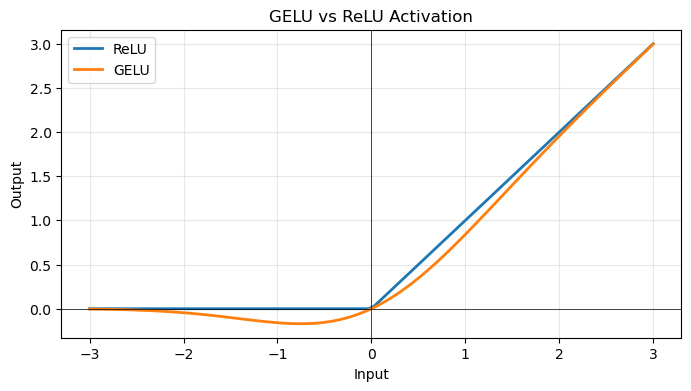

In [36]:
# Visualize GELU vs ReLU
import matplotlib.pyplot as plt

x = torch.linspace(-3, 3, 100)
plt.figure(figsize=(8, 4))
plt.plot(x.numpy(), F.relu(x).numpy(), label='ReLU', linewidth=2)
plt.plot(x.numpy(), F.gelu(x).numpy(), label='GELU', linewidth=2)
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('GELU vs ReLU Activation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.show()

💡 **Key Insight**: GELU (Gaussian Error Linear Unit) is smoother than ReLU — it doesn't have a hard kink at 0. This helps with gradient flow and is now standard in Transformers (GPT, BERT, ViT all use GELU).

---

### Part 6: Transformer Encoder Block

🎯 **What it does**: Combine attention and FFN with residual connections and layer normalization

🔧 **Why it matters**: ViT uses **Pre-LN** (LayerNorm before attention/FFN), same as LLaMA! This is more stable than the original Post-LN Transformer.

In [37]:
class TransformerBlock(nn.Module):
    """Pre-LN Transformer block (same architecture as LLaMA).
    
    Structure:
        x → LN → Attention → + → LN → FFN → +
        └──────────────────────┘   └────────┘
              residual              residual
    """
    
    def __init__(self, config):
        super().__init__()
        self.norm1 = nn.LayerNorm(config.d_model)
        self.attn = MultiHeadAttention(config)
        self.norm2 = nn.LayerNorm(config.d_model)
        self.ffn = FeedForward(config)
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, x):
        # Pre-LN: normalize BEFORE attention/FFN
        x = x + self.dropout(self.attn(self.norm1(x)))
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x

In [38]:
# Test transformer block
block = TransformerBlock(config)
test_input = torch.randn(2, config.n_patches + 1, config.d_model)
block_out = block(test_input)

print(f"Input shape: {test_input.shape}")
print(f"Block output shape: {block_out.shape}")
print(f"Number of parameters: {sum(p.numel() for p in block.parameters()):,}")

Input shape: torch.Size([2, 65, 256])
Block output shape: torch.Size([2, 65, 256])
Number of parameters: 526,336


💡 **Key Insight**: Pre-LN vs Post-LN:
- **Post-LN** (original Transformer): `x + Attention(x)` → `LayerNorm`
- **Pre-LN** (ViT, LLaMA): `x + Attention(LayerNorm(x))`

Pre-LN is more stable for deep networks because gradients don't explode through layer norms.

---

### Part 7: Complete ViT Model

🎯 **What it does**: Assemble all components into a full Vision Transformer

🔧 **Why it matters**: The CLS token strategy — prepending a learnable token that aggregates global information through attention.

In [39]:
class ViT(nn.Module):
    """Vision Transformer for image classification.
    
    Architecture:
    1. Patch embedding: image → sequence of patch embeddings
    2. Prepend CLS token: learnable classification token
    3. Add positional encoding
    4. Transformer encoder: N layers of self-attention + FFN
    5. MLP head: CLS token → class predictions
    """
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        # Patch embedding
        self.patch_embed = PatchEmbedding(config)
        
        # CLS token: learnable, prepended to sequence
        self.cls_token = nn.Parameter(torch.randn(1, 1, config.d_model) * 0.02)
        
        # Positional encoding (learned 1D)
        self.pos_embed = LearnedPositionalEncoding(config)
        self.dropout = nn.Dropout(config.dropout)
        
        # Transformer encoder blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(config) for _ in range(config.n_layers)
        ])
        
        # Final layer norm (applied to CLS token before classification)
        self.norm = nn.LayerNorm(config.d_model)
        
        # Classification head
        self.head = nn.Linear(config.d_model, config.n_classes)
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.trunc_normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)
    
    def forward(self, x, return_features=False):
        B = x.shape[0]
        
        # 1. Patch embedding: (B, 3, H, W) → (B, n_patches, d_model)
        x = self.patch_embed(x)
        
        # 2. Prepend CLS token: (B, n_patches, d_model) → (B, n_patches+1, d_model)
        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B, 1, d_model)
        x = torch.cat([cls_tokens, x], dim=1)
        
        # 3. Add positional encoding
        x = self.pos_embed(x)
        x = self.dropout(x)
        
        # 4. Transformer encoder
        for block in self.blocks:
            x = block(x)
        
        # 5. Extract CLS token and classify
        x = self.norm(x)
        cls_output = x[:, 0]  # (B, d_model) - just the CLS token
        
        if return_features:
            return cls_output
        
        logits = self.head(cls_output)  # (B, n_classes)
        return logits

In [40]:
# Create model and test
model = ViT(config).to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

# Test forward pass
dummy_batch = torch.randn(4, 3, 32, 32).to(device)
logits = model(dummy_batch)

print(f"\nInput shape: {dummy_batch.shape}")
print(f"Output shape: {logits.shape}")
print(f"Expected: (4, {config.n_classes})")

Total parameters: 3,190,538

Input shape: torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 10])
Expected: (4, 10)


💡 **Key Insight**: The CLS token is a clever trick borrowed from BERT:
1. It's a learnable vector prepended to the sequence
2. Through self-attention, it can attend to ALL patches
3. After N layers, it contains a global summary of the image
4. We use only this token (ignoring patch tokens) for classification

Alternative: Average all patch embeddings (called "global average pooling"). Both work!

---

### Part 8: Data Pipeline (CIFAR-10)

🎯 **What it does**: Prepare CIFAR-10 dataset with appropriate augmentations

🔧 **Why it matters**: Data augmentation is crucial for ViT — it doesn't have the inductive biases (translation invariance) that CNNs have built-in.

In [41]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# CIFAR-10 class names
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']

# Training transforms with augmentation
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Test transforms (no augmentation)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

In [42]:
# Load CIFAR-10 (with fallback to synthetic data)
from torch.utils.data import TensorDataset

print("Attempting to load CIFAR-10 dataset...")
print("-" * 60)

try:
    train_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=train_transform
    )
    test_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=test_transform
    )
    
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)
    
    print(f"✅ CIFAR-10 loaded successfully!")
    print(f"Training samples: {len(train_dataset):,}")
    print(f"Test samples: {len(test_dataset):,}")
    print(f"Training batches per epoch: {len(train_loader)}")
    
except Exception as e:
    print(f"⚠️  CIFAR-10 download failed: {str(e)[:100]}...")
    print("\n📝 Creating synthetic dataset for demonstration...")
    
    # Generate random images (1000 training, 200 test)
    fake_train_images = torch.randn(1000, 3, 32, 32)
    fake_train_labels = torch.randint(0, 10, (1000,))
    fake_test_images = torch.randn(200, 3, 32, 32)
    fake_test_labels = torch.randint(0, 10, (200,))
    
    train_dataset = TensorDataset(fake_train_images, fake_train_labels)
    test_dataset = TensorDataset(fake_test_images, fake_test_labels)
    
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    
    print(f"✅ Synthetic dataset created!")
    print(f"Training samples: {len(train_dataset):,}")
    print(f"Test samples: {len(test_dataset):,}")
    print(f"Training batches per epoch: {len(train_loader)}")
    print("\n⚠️  Note: Using random data for demonstration. Results won't be meaningful.")
    print("   For real training, download CIFAR-10 manually or run outside corporate network.")

Attempting to load CIFAR-10 dataset...
------------------------------------------------------------
⚠️  CIFAR-10 download failed: <urlopen error [Errno 8] nodename nor servname provided, or not known>...

📝 Creating synthetic dataset for demonstration...
✅ Synthetic dataset created!
Training samples: 1,000
Test samples: 200
Training batches per epoch: 8

⚠️  Note: Using random data for demonstration. Results won't be meaningful.
   For real training, download CIFAR-10 manually or run outside corporate network.


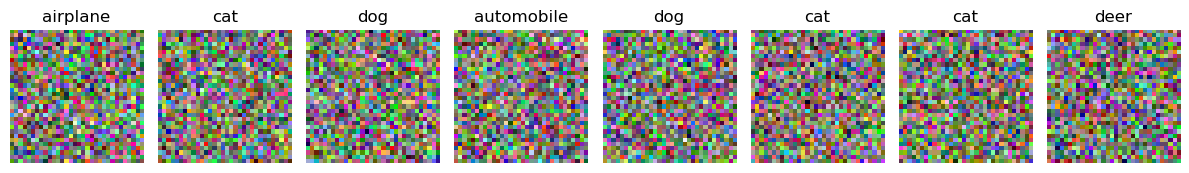

In [43]:
# Visualize some samples
def show_samples(loader, n=8):
    images, labels = next(iter(loader))
    
    # Denormalize for visualization
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    images_vis = images[:n] * std + mean
    
    fig, axes = plt.subplots(1, n, figsize=(12, 2))
    for i, ax in enumerate(axes):
        img = images_vis[i].permute(1, 2, 0).clip(0, 1)
        ax.imshow(img)
        ax.set_title(CLASSES[labels[i]])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_loader)

💡 **Key Insight**: ViT lacks CNN's inductive biases:
- **Translation equivariance**: CNN features shift when input shifts
- **Locality**: CNNs process local neighborhoods first

ViT must learn these from data, so it needs:
1. More data (or pretrain on ImageNet-21k)
2. Strong augmentation (RandomCrop, HorizontalFlip, etc.)
3. Regularization (dropout, label smoothing)

---

### Part 9: Training Loop

🎯 **What it does**: Train ViT on CIFAR-10 classification

🔧 **Why it matters**: Demonstrates supervised training with cross-entropy loss. We'll use AdamW optimizer with warmup + cosine decay.

In [44]:
def get_lr_scheduler(optimizer, warmup_epochs, total_epochs, steps_per_epoch):
    """Linear warmup followed by cosine decay."""
    warmup_steps = warmup_epochs * steps_per_epoch
    total_steps = total_epochs * steps_per_epoch
    
    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        else:
            progress = (step - warmup_steps) / (total_steps - warmup_steps)
            return 0.5 * (1 + math.cos(math.pi * progress))
    
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [45]:
# Training configuration
EPOCHS = 50
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 5
GRAD_CLIP = 1.0

# Initialize model, optimizer, scheduler
model = ViT(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = get_lr_scheduler(optimizer, WARMUP_EPOCHS, EPOCHS, len(train_loader))
criterion = nn.CrossEntropyLoss()

print(f"Training for {EPOCHS} epochs")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Weight decay: {WEIGHT_DECAY}")
print(f"Warmup epochs: {WARMUP_EPOCHS}")

Training for 50 epochs
Learning rate: 0.0003
Weight decay: 0.05
Warmup epochs: 5


In [46]:
def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        logits = model(images)
        loss = criterion(logits, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()
        
        # Track metrics
        total_loss += loss.item()
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(loader), 100 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        logits = model(images)
        loss = criterion(logits, labels)
        
        total_loss += loss.item()
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(loader), 100 * correct / total

In [47]:
# Training loop
train_losses, test_losses = [], []
train_accs, test_accs = [], []
best_acc = 0

print("Starting training...")
print("-" * 60)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    # Save best model
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'config': config,
            'best_acc': best_acc
        }, 'vit_checkpoint.pt')
    
    # Print progress
    lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | "
          f"LR: {lr:.6f}")

print("-" * 60)
print(f"Best Test Accuracy: {best_acc:.2f}%")

Starting training...
------------------------------------------------------------
Epoch   1/50 | Train Loss: 2.3524 | Train Acc: 9.40% | Test Loss: 2.3621 | Test Acc: 11.00% | LR: 0.000060
Epoch   2/50 | Train Loss: 2.3208 | Train Acc: 10.50% | Test Loss: 2.3285 | Test Acc: 11.50% | LR: 0.000120
Epoch   3/50 | Train Loss: 2.3053 | Train Acc: 12.90% | Test Loss: 2.3694 | Test Acc: 10.50% | LR: 0.000180
Epoch   4/50 | Train Loss: 2.2914 | Train Acc: 12.70% | Test Loss: 2.3290 | Test Acc: 13.00% | LR: 0.000240
Epoch   5/50 | Train Loss: 2.2807 | Train Acc: 14.60% | Test Loss: 2.3753 | Test Acc: 10.00% | LR: 0.000300
Epoch   6/50 | Train Loss: 2.2710 | Train Acc: 15.30% | Test Loss: 2.3640 | Test Acc: 8.00% | LR: 0.000300
Epoch   7/50 | Train Loss: 2.2263 | Train Acc: 17.50% | Test Loss: 2.4625 | Test Acc: 9.00% | LR: 0.000299
Epoch   8/50 | Train Loss: 2.2018 | Train Acc: 18.20% | Test Loss: 2.4464 | Test Acc: 8.50% | LR: 0.000297
Epoch   9/50 | Train Loss: 2.1819 | Train Acc: 20.00% | Te

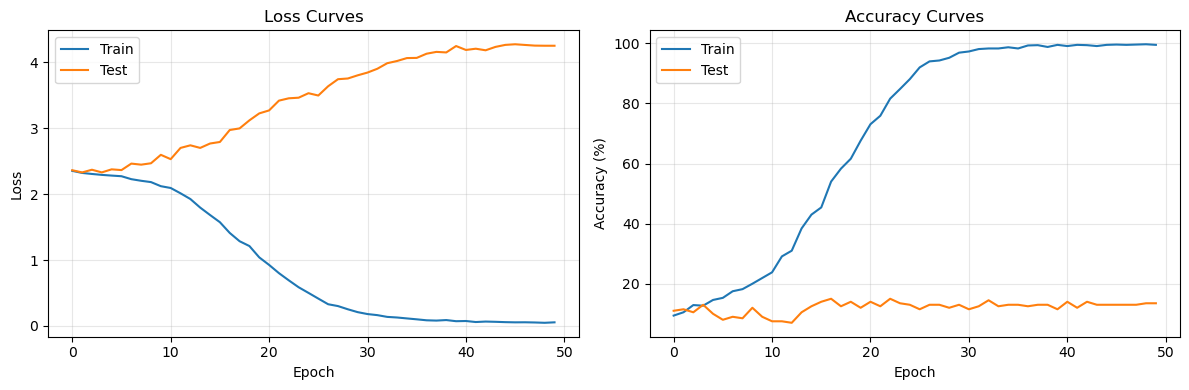

In [48]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train')
ax1.plot(test_losses, label='Test')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label='Train')
ax2.plot(test_accs, label='Test')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

💡 **Key Insight**: Our small ViT on CIFAR-10 should reach ~70-80% accuracy. The original ViT was pretrained on ImageNet-21k (14M images) then fine-tuned — that's why it beats CNNs. From scratch on small datasets, CNNs still win due to their built-in inductive biases.

---

### Part 10: Attention Visualization

🎯 **What it does**: Visualize what the model attends to

🔧 **Why it matters**: Attention maps show how ViT "looks" at images — often attending to semantically meaningful regions.

In [49]:
class ViTWithAttention(ViT):
    """ViT that also returns attention weights for visualization."""
    
    def forward(self, x, return_attention=False):
        B = x.shape[0]
        
        # Patch embedding
        x = self.patch_embed(x)
        
        # Prepend CLS token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        
        # Add positional encoding
        x = self.pos_embed(x)
        x = self.dropout(x)
        
        # Transformer encoder with attention capture
        attentions = []
        for block in self.blocks:
            if return_attention:
                # Manually compute attention to capture weights
                normed = block.norm1(x)
                B, N, C = normed.shape
                qkv = block.attn.qkv(normed).reshape(B, N, 3, block.attn.n_heads, block.attn.head_dim)
                qkv = qkv.permute(2, 0, 3, 1, 4)
                q, k, v = qkv[0], qkv[1], qkv[2]
                attn_weights = (q @ k.transpose(-2, -1)) * block.attn.scale
                attn_weights = F.softmax(attn_weights, dim=-1)
                attentions.append(attn_weights.detach())
            x = block(x)
        
        # Classification
        x = self.norm(x)
        cls_output = x[:, 0]
        logits = self.head(cls_output)
        
        if return_attention:
            return logits, attentions
        return logits

In [50]:
def visualize_attention(model, image, layer_idx=-1, head_idx=0):
    """Visualize attention from CLS token to all patches."""
    model.eval()
    
    # Get attention weights
    with torch.no_grad():
        logits, attentions = model(image.unsqueeze(0).to(device), return_attention=True)
    
    # Get attention from specified layer and head
    attn = attentions[layer_idx][0, head_idx]  # (seq_len, seq_len)
    
    # CLS token attention to patches (first row, excluding CLS position)
    cls_attn = attn[0, 1:].cpu()  # (n_patches,)
    
    # Reshape to 2D
    grid_size = int(math.sqrt(cls_attn.shape[0]))
    cls_attn = cls_attn.reshape(grid_size, grid_size)
    
    # Denormalize image for display
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    img_display = (image.cpu() * std + mean).permute(1, 2, 0).clip(0, 1)
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    
    axes[0].imshow(img_display)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(cls_attn, cmap='hot')
    axes[1].set_title(f'CLS Attention (Layer {layer_idx}, Head {head_idx})')
    axes[1].axis('off')
    
    # Overlay attention on image
    attn_upscaled = F.interpolate(
        cls_attn.unsqueeze(0).unsqueeze(0), 
        size=(32, 32), mode='bilinear', align_corners=False
    )[0, 0]
    axes[2].imshow(img_display)
    axes[2].imshow(attn_upscaled, cmap='hot', alpha=0.5)
    axes[2].set_title('Attention Overlay')
    axes[2].axis('off')
    
    # Get prediction
    pred = logits.argmax(1).item()
    plt.suptitle(f'Predicted: {CLASSES[pred]}')
    plt.tight_layout()
    plt.show()

True label: bird


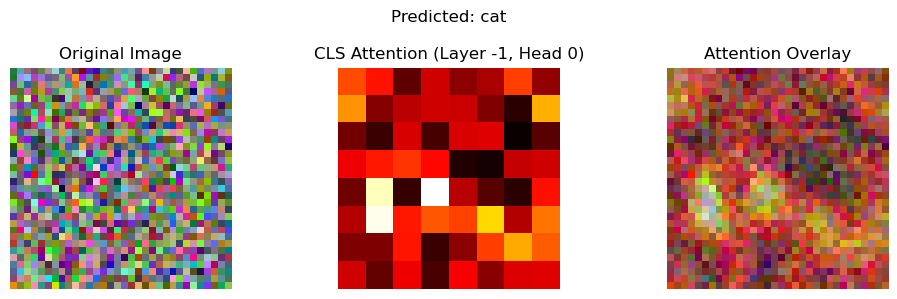

True label: cat


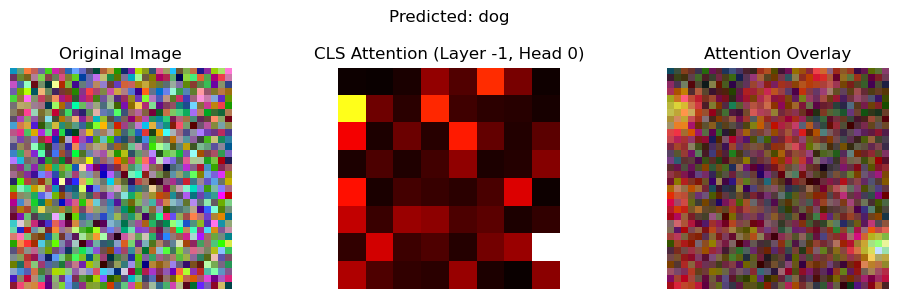

True label: dog


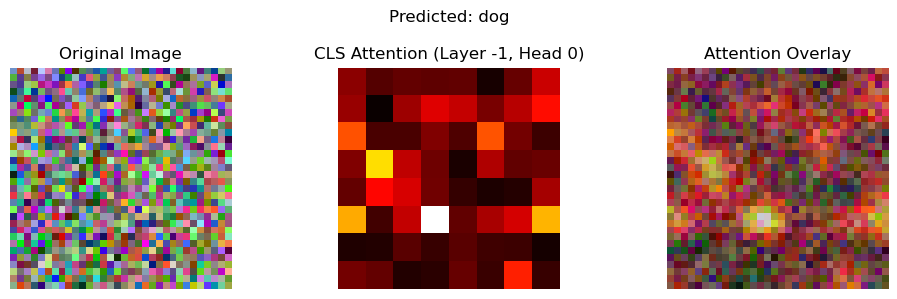

True label: cat


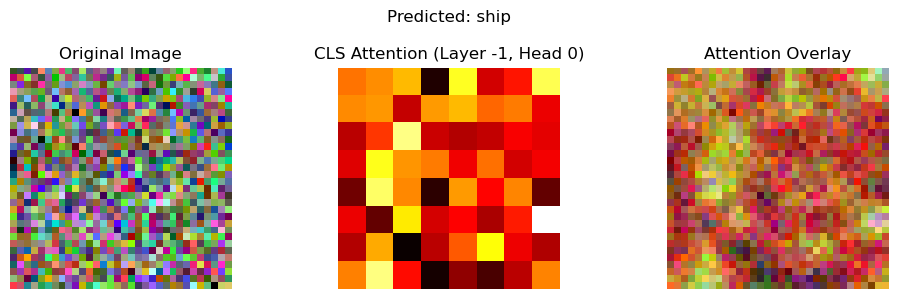

In [51]:
# Load best model and visualize
vis_model = ViTWithAttention(config).to(device)
checkpoint = torch.load('vit_checkpoint.pt', map_location=device, weights_only=False)
vis_model.load_state_dict(checkpoint['model_state_dict'])

# Get some test images
test_images, test_labels = next(iter(test_loader))

# Visualize attention for first few images
for i in range(4):
    print(f"True label: {CLASSES[test_labels[i]]}")
    visualize_attention(vis_model, test_images[i], layer_idx=-1, head_idx=0)

💡 **Key Insight**: ViT attention often focuses on:
- Object boundaries and contours
- Semantically important regions (eyes, wheels, etc.)
- Different heads attend to different features (like multi-scale in CNNs)

Early layers have more diffuse attention; later layers are more focused.

---

### Summary

#### What We Built

A complete **Vision Transformer (ViT)** from scratch:

| Component | Key Idea |
|-----------|----------|
| **Patch Embedding** | Image → sequence of patches via Conv2d |
| **CLS Token** | Learnable token for global aggregation |
| **Positional Encoding** | Learned 1D embeddings |
| **Self-Attention** | Global receptive field from layer 1 |
| **Pre-LN Blocks** | More stable than Post-LN |
| **Classification Head** | CLS token → class logits |

#### ViT vs CNN

| Aspect | CNN | ViT |
|--------|-----|-----|
| Receptive field | Grows with depth | Global from layer 1 |
| Inductive bias | Strong (locality, translation) | Weak (must learn) |
| Data efficiency | Better on small data | Needs more data |
| Scalability | Saturates | Scales better |

#### Next Steps

**Next notebook**: `jepa_from_scratch.ipynb` — We'll use this ViT architecture as the backbone for I-JEPA, a self-supervised learning approach that predicts in latent space instead of pixel space!

---

🎉 **Congratulations!** You've built a Vision Transformer from scratch. This is the foundation for:
- JEPA (self-supervised learning)
- CLIP (vision-language models)
- Diffusion models with Transformer backbones (DiT)
- And many more modern architectures!

---

### 🗿 Chapter 4 Complete: Vision Conquered by Attention

*"Transformers won't work on images."*  
*"You need convolutions for vision."*  
*"Inductive biases are essential."*  
*"This will never beat ResNets."*

They said it couldn't be done. The experts doubted.

And then Dosovitskiy et al. proved them wrong.

---

#### 🎨 What You Built

You didn't just implement ViT. You **bridged two worlds:**
- ✅ **Patch embeddings** — Images as sequences (the key insight)
- ✅ **Position encoding** — 1D learned positions for 2D images  
- ✅ **CLS token** — A single learnable vector that "asks the question"
- ✅ **Self-attention on images** — Global receptive field from layer 1
- ✅ **Attention visualization** — See what the model "sees"

You proved to yourself that the wall between NLP and vision was **an illusion**. Transformers are universal. Attention is all you need — even for pixels.

---

#### 🧠 But There's a Problem...

ViT is supervised. It needs labels. Millions of them.

But humans don't learn that way. A child doesn't need a million labeled images to understand *"dog"* vs *"cat."* They just... **observe the world.**

In 2023, Yann LeCun asked: *"What if models could learn like humans — by predicting what matters, not by reconstructing pixels?"*

**Chapter 5 awaits:** Where prediction replaces reconstruction, where world models emerge from raw observation, where the future of AI might just be hiding.

---

> *"While the Transformer architecture has become the de-facto standard for natural language processing tasks, its applications to computer vision remain limited... We show that this reliance on CNNs is not necessary and a pure transformer applied directly to sequences of image patches can perform very well on image classification tasks."*  
> — **Dosovitskiy et al., "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale" (2020)**

The impossible became possible. **You built it yourself.**

**The world model sanctum awaits.** 🌍🧠

📖 **Next Chapter**: [The World Model Sanctum](5.%20jepa_from_scratch.ipynb) →